In [1]:
import os
import scanpy as sc
import pandas as pd
import numpy as np
from scipy import sparse


/home/yuanyuan.fu/bin/miniconda3/envs/iterative_scANVI_May9/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/yuanyuan.fu/bin/miniconda3/envs/iterative_scANVI_May9/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/home/yuanyuan.fu/bin/miniconda3/envs/iterative_scANVI_May9/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/home/yuanyuan.fu/bin/miniconda3/envs/iterative_scANVI_May9/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/home/

In [2]:
data_dir = "/allen/programs/celltypes/workgroups/rnaseqanalysis/HMBA/Aim1_Atlases/BasalGanglia_paper_package/data/xspecies"

work_dir = "/allen/programs/celltypes/workgroups/rnaseqanalysis/HMBA/Aim1_Atlases/BasalGanglia_paper_package/analysis/neurotransmitter"
os.makedirs(work_dir, exist_ok=True)

In [3]:
adata = sc.read_h5ad(data_dir + "/Consensus_HMBA_basalganglia_AIT_pre-print.h5ad")
adata

AnnData object with n_obs × n_vars = 1896133 × 16630
    obs: 'Neighborhood', 'Class', 'Subclass', 'Group', 'Cluster', 'cluster_id', 'cell_type_ontology_term', 'load_id', 'donor_id', 'assay', 'assay_ontology_term_id', 'organism', 'organism_ontology_term_id', 'development_stage', 'anatomical_region', 'anatomical_region_merged', 'anatomical_region_ontology_term_id', 'brain_region_ontology_term_id', 'self_reported_sex', 'self_reported_sex_ontology_term_id', 'self_reported_ethnicity', 'self_reported_ethnicity_ontology_term_id', 'disease', 'disease_ontology_term_id', 'suspension_type', 'is_primary_data', 'atac_confidently_mapped_read_pairs', 'atac_fraction_of_genome_in_peaks', 'atac_fraction_of_high_quality_fragments_in_cells', 'atac_fraction_of_high_quality_fragments_overlapping_tss', 'atac_fraction_of_high_quality_fragments_overlapping_peaks', 'atac_fraction_of_transposition_events_in_peaks_in_cells', 'atac_mean_raw_read_pairs_per_cell', 'atac_median_high_quality_fragments_per_cell', 'ata

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm, colors
from anndata import AnnData

def species_region_dotplot_dual(
    adata: AnnData,
    species_key: str = "organism",
    region_key: str = "anatomical_region",
    donor_key: str = "donor_id",
    *,
    size_from: str = "cells",           # fixed: 'cells' → marker area
    color_from: str = "donors",         # fixed: 'donors' → marker color
    min_dot_size: float = 30,
    max_dot_size: float = 400,
    size_norm: str = "sqrt",            # {'linear','sqrt','log'}
    color_norm: str = "sqrt",           # {'linear','sqrt','log'}
    cmap: str = "viridis",
    annotate: bool = False,             # overlay numeric labels (cells)
    sort_regions_by_coverage: bool = True,
    region_order: list[str] | None = None,
    figsize=(8, 4),
    add_colorbar: bool = True,
):
    """
    Dot-plot with dot SIZE = cell counts and dot COLOR = donor counts
    for each (species, anatomical_region).

    Returns
    -------
    cells_df  : regions × species cell counts
    donors_df : regions × species donor counts
    """
    # --- checks ---
    for key in [species_key, region_key]:
        if key not in adata.obs.columns:
            raise KeyError(f"'{key}' not found in adata.obs")
    if donor_key not in adata.obs.columns:
        raise KeyError(f"'{donor_key}' not found in adata.obs")

    obs = adata.obs[[species_key, region_key, donor_key]].copy()

    # --- tables ---
    cells_df = obs.groupby([region_key, species_key]).size().unstack(fill_value=0)
    donors_df = (obs.dropna()
                   .drop_duplicates(subset=[region_key, species_key, donor_key])
                   .groupby([region_key, species_key])[donor_key]
                   .nunique()
                   .unstack(fill_value=0))

    # ensure aligned indices/columns
    all_regions = sorted(set(cells_df.index) | set(donors_df.index))
    all_species = sorted(set(cells_df.columns) | set(donors_df.columns))
    cells_df = cells_df.reindex(index=all_regions, columns=all_species, fill_value=0)
    donors_df = donors_df.reindex(index=all_regions, columns=all_species, fill_value=0)

    # region order
    presence_df = (cells_df > 0) | (donors_df > 0)
    if region_order is not None:
        region_order = [r for r in region_order if r in presence_df.index]
        cells_df   = cells_df.loc[region_order]
        donors_df  = donors_df.loc[region_order]
        presence_df = presence_df.loc[region_order]
    elif sort_regions_by_coverage:
        order = presence_df.sum(axis=1).sort_values(ascending=False).index
        cells_df   = cells_df.loc[order]
        donors_df  = donors_df.loc[order]
        presence_df = presence_df.loc[order]

    regions = cells_df.index.tolist()
    species = cells_df.columns.tolist()

    # --- helper normalizers ---
    def _norm_vals(A, mode):
        A = np.asarray(A, float)
        if not np.any(A > 0):
            return np.zeros_like(A)
        if mode == "linear":
            vmin = A[A>0].min()
            vmax = A.max()
            return (A - vmin) / (vmax - vmin + 1e-12)
        elif mode == "sqrt":
            vmin = np.sqrt(A[A>0].min())
            vmax = np.sqrt(A.max())
            return (np.sqrt(A) - vmin) / (vmax - vmin + 1e-12)
        elif mode == "log":
            vmin = np.log1p(A[A>0].min())
            vmax = np.log1p(A.max())
            return (np.log1p(A) - vmin) / (vmax - vmin + 1e-12)
        else:
            raise ValueError("mode must be in {'linear','sqrt','log'}")

    # sizes from CELLS
    size_raw = cells_df.values
    size_scaled = _norm_vals(size_raw, size_norm)
    sizes = np.where(size_raw > 0,
                     min_dot_size + (max_dot_size - min_dot_size) * np.clip(size_scaled, 0, 1),
                     0.0)

    # colors from DONORS
    color_raw = donors_df.values
    color_scaled = _norm_vals(color_raw, color_norm)
    cmap_obj = cm.get_cmap(cmap)
    # map to RGBA; 0 entries → transparent
    facecolors = np.zeros((*color_scaled.shape, 4), dtype=float)
    mask_pos = (cells_df.values > 0)  # plot a coin only if present
    facecolors[mask_pos] = cmap_obj(np.clip(color_scaled[mask_pos], 0, 1))
    facecolors[~mask_pos, 3] = 0.0  # fully transparent where no sampling

    # --- scatter coords ---
    X, Y, S, C = [], [], [], []
    labels = []  # annotate with cell counts if requested
    for i, r in enumerate(regions):
        for j, sp in enumerate(species):
            if sizes[i, j] > 0:
                X.append(j)
                Y.append(i)
                S.append(sizes[i, j])
                C.append(facecolors[i, j])
                if annotate:
                    labels.append((j, i, int(cells_df.iloc[i, j])))

    # --- plot ---
    fig, ax = plt.subplots(figsize=figsize)
    ax.scatter(X, Y, s=S, facecolors=C, edgecolors="black", linewidths=0.5)

    if annotate and labels:
        for (jx, iy, t) in labels:
            ax.text(jx, iy, str(t), ha="center", va="center", fontsize=9)

    ax.set_xticks(range(len(species)))
    ax.set_xticklabels(species, rotation=90, ha="right")
    ax.set_yticks(range(len(regions)))
    ax.set_yticklabels(regions)
    ax.invert_yaxis()
    ax.set_xlabel("Species")
    ax.set_ylabel("Region")
    ax.set_title("Sampling coverage (size = cells, color = donors)")
    ax.grid(axis="both", linestyle=":", alpha=0.3)

    # colorbar for donor counts
    if add_colorbar:
        # build a ScalarMappable using donors range
        v = donors_df.values
        vmin = v[v>0].min() if (v>0).any() else 0.0
        vmax = v.max() if v.size else 1.0
        if vmin == 0 and vmax == 0:
            vmin, vmax = 0, 1
        # choose the same norm used for color mapping (for ticks, show raw donors)
        # we’ll keep the color scale linear in the mappable, but label with raw donors.
        norm = colors.Normalize(vmin=vmin, vmax=vmax)
        sm = cm.ScalarMappable(norm=norm, cmap=cmap_obj)
        cbar = plt.colorbar(sm, ax=ax, pad=0.02)
        cbar.set_label("Donor counts")
        # optional: nicer integer ticks
        ticks = np.linspace(vmin, vmax, num=min(6, int(vmax - vmin + 1)))
        cbar.set_ticks(np.unique(np.round(ticks).astype(int)))

    plt.tight_layout()
    return cells_df, donors_df


/scratch/fast/4731567/ipykernel_2748958/2251727517.py:104: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_obj = cm.get_cmap(cmap)


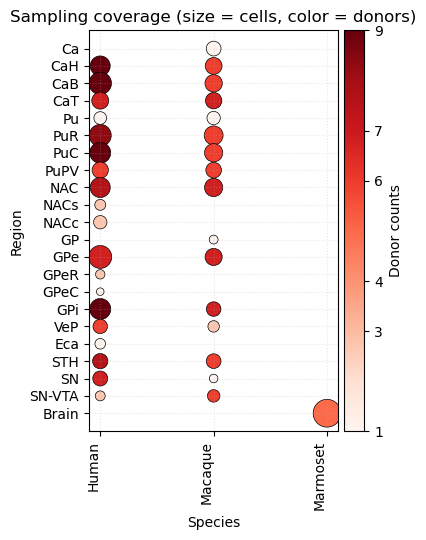

In [17]:
my_anatomical_region_order = ['Ca','CaH', 'CaB', 'CaT', 'Pu', 'PuR', 'PuC', 'PuPV', 'NAC', 'NACs', 'NACc', 'GP', 'GPe', 'GPeR','GPeC', 'GPi', 'VeP', 'Eca', 'STH', 'SN', 'SN-VTA', 'Brain' ]

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
cells_df, donors_df = species_region_dotplot_dual(
    adata,
    species_key="organism",
    region_key="anatomical_region",
    donor_key="donor_id",
    size_norm="sqrt",     # sqrt scaling is visually robust
    color_norm="sqrt",
    cmap="Reds",
    annotate=False,
    figsize=(4.2, 5.5),
    region_order = my_anatomical_region_order 
)
plt.savefig("species_region_dotplot_sizeCellcolorDonor-Reds.pdf", bbox_inches="tight")
#Dot area is proportional to the square root of the number of cells, and color intensity reflects donor counts.

In [13]:
import os
print(os.getcwd())

/home/yuanyuan.fu/yyfu/yyf_scripts/HMBA_hu_all/scripts_for_atlas


/scratch/fast/4731567/ipykernel_2748958/2251727517.py:104: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_obj = cm.get_cmap(cmap)


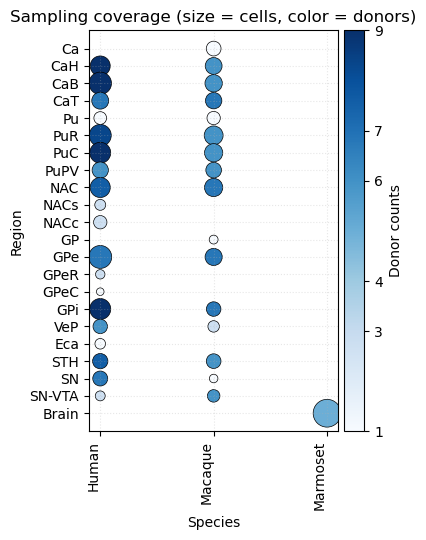

In [18]:
cells_df, donors_df = species_region_dotplot_dual(
    adata,
    species_key="organism",
    region_key="anatomical_region",
    donor_key="donor_id",
    size_norm="sqrt",     
    color_norm="sqrt",
    cmap="Blues",
    annotate=False,
    figsize=(4.2, 5.5),
    region_order = my_anatomical_region_order 
)
plt.savefig("species_region_dotplot_sizeCellcolorDonor-Bules.pdf", bbox_inches="tight")
#Dot area is proportional to the square root of the number of cells, and color intensity reflects donor counts.

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from anndata import AnnData

def species_region_dotplot(
    adata: AnnData,
    species_key: str = "organism",
    region_key: str = "anatomical_region",   
    donor_key: str = "donor_id",
    size_by: str = "cells",          # {"cells","donors","presence"}
    min_dot_size: float = 30,
    max_dot_size: float = 400,
    annotate: bool = False,          # True -> values
    sort_regions_by_coverage: bool = True,
    region_order: list[str] | None = None,   
    figsize=(8, 4),
):
    """
    Create a simple dot-plot showing whether each species has sampling in each region,
    with dot size optionally reflecting cell counts or donor counts.

    Parameters
    ----------
    adata : AnnData
        Integrated AnnData containing multiple species and regions.
    species_key : str
        .obs column for species (e.g., 'organism').
    region_key : str
        .obs column for region / dissection / area.
    donor_key : str
        .obs column for donor IDs (for size_by='donors').
    size_by : {'cells','donors','presence'}
        What determines dot size:
        - 'cells'     : number of cells per (species, region)
        - 'donors'    : number of unique donors per (species, region)
        - 'presence'  : binary presence/absence (uniform dot size)
    min_dot_size, max_dot_size : float
        Range of marker sizes.
    annotate : bool
        If True, write the count (cells or donors) at each dot.
    sort_regions_by_coverage : bool
        If True, order regions by how many species are present (descending).
    region_order : list[str], optional
        Manual region order (overrides sort_regions_by_coverage).
    figsize : tuple
        Figure size.

    Returns
    -------
    counts_df : pd.DataFrame
        Wide table (regions × species) with counts used for dot sizes.
    presence_df : pd.DataFrame
        Boolean table (regions × species) for sampling presence.
    """
    # --- Basic checks ---
    for key in [species_key, region_key]:
        if key not in adata.obs.columns:
            raise KeyError(f"'{key}' not found in adata.obs")
    if size_by not in {"cells","donors","presence"}:
        raise ValueError("size_by must be one of {'cells','donors','presence'}")

    df = adata.obs[[species_key, region_key]].copy()

    # Compute counts per (species, region)
    if size_by == "cells":
        grouped = df.groupby([region_key, species_key]).size()
    elif size_by == "donors":
        if donor_key not in adata.obs.columns:
            raise KeyError(f"'{donor_key}' not found in adata.obs (required for size_by='donors')")
        tmp = adata.obs[[region_key, species_key, donor_key]].dropna()
        grouped = tmp.drop_duplicates().groupby([region_key, species_key])[donor_key].nunique()
    else:  # presence
        grouped = df.groupby([region_key, species_key]).size()
        grouped = (grouped > 0).astype(int)

    counts_df = grouped.unstack(fill_value=0)

    # Presence (boolean) for quick coverage view
    presence_df = (counts_df > 0)

    # Region sorting logic
    if region_order is not None:
        region_order = [r for r in region_order if r in counts_df.index]
        counts_df = counts_df.loc[region_order]
        presence_df = presence_df.loc[region_order]
    elif sort_regions_by_coverage:
        order = presence_df.sum(axis=1).sort_values(ascending=False).index
        counts_df = counts_df.loc[order]
        presence_df = presence_df.loc[order]

    # Map counts to dot sizes
    if size_by == "presence":
        sizes = counts_df.where(counts_df==0, 1)  # 0 or 1
    else:
        sizes = counts_df.copy()

    # Normalize to marker sizes (avoid division by zero)
    values = sizes.values.astype(float)
    vmax = values.max() if values.size and values.max() > 0 else 1.0
    vmin = values[values>0].min() if (values>0).any() else 1.0
    scaled = np.zeros_like(values, dtype=float)
    mask = values > 0
    scaled[mask] = (np.sqrt(values[mask]) - np.sqrt(vmin)) / (np.sqrt(vmax) - np.sqrt(vmin) + 1e-9)
    scaled = min_dot_size + (max_dot_size - min_dot_size) * np.clip(scaled, 0, 1)

    # Prepare coordinates
    regions = counts_df.index.tolist()
    species = counts_df.columns.tolist()
    X, Y, S = [], [], []
    texts = []

    for i, r in enumerate(regions):
        for j, sp in enumerate(species):
            X.append(j)
            Y.append(i)
            S.append(scaled[i, j] if counts_df.iloc[i, j] > 0 else 0.0)
            if annotate and counts_df.iloc[i, j] > 0:
                texts.append((j, i, str(int(counts_df.iloc[i, j]))))

    # --- Plot ---
    fig, ax = plt.subplots(figsize=figsize)
    ax.scatter(X, Y, s=S, edgecolors="black", facecolors="none")

    if annotate and texts:
        for (jx, iy, t) in texts:
            ax.text(jx, iy, t, ha="center", va="center", fontsize=9)

    ax.set_xticks(range(len(species)))
    ax.set_xticklabels(species, rotation=90, ha="right")
    ax.set_yticks(range(len(regions)))
    ax.set_yticklabels(regions)
    ax.invert_yaxis()
    ax.set_xlabel("Species")
    ax.set_ylabel("Region")
    title_map = {"cells":"cell counts", "donors":"donor counts", "presence":"presence"}
    ax.set_title(f"Sampling coverage by {title_map[size_by]}")
    ax.grid(axis="both", linestyle=":", alpha=0.3)
    plt.tight_layout()
    return counts_df, presence_df


In [22]:
my_anatomical_region_order = ['Ca','CaH', 'CaB', 'CaT', 'Pu', 'PuR', 'PuC', 'PuPV', 'NAC', 'NACs', 'NACc', 'GP', 'GPe', 'GPeR','GPeC', 'GPi', 'VeP', 'Eca', 'STH', 'SN', 'SN-VTA', 'Brain' ]

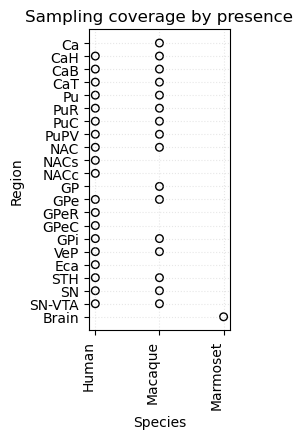

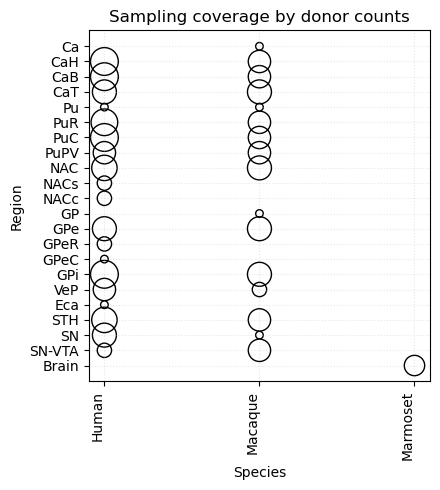

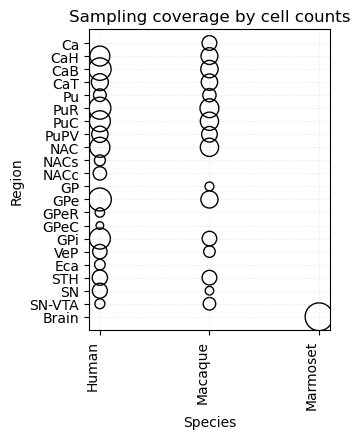

In [24]:
counts, presence = species_region_dotplot(
    adata,
    species_key="organism",
    region_key="anatomical_region",
    size_by="presence", # {"cells","donors","presence"}
    region_order=my_anatomical_region_order,
    figsize=(2.5,4.5)
)

counts, presence = species_region_dotplot(
    adata,
    species_key="organism",
    region_key="anatomical_region",
    size_by="donors",
    region_order=my_anatomical_region_order,
    figsize=(4.5,5)
)

counts, presence = species_region_dotplot(
    adata,
    species_key="organism",
    region_key="anatomical_region",
    size_by="cells",
    region_order=my_anatomical_region_order,
    figsize=(3.5,4.5)
)

In [27]:
set(adata.obs['anatomical_region_merged'])

{'Brain', 'Ca', 'Eca', 'GP', 'GPe', 'GPi', 'NAC', 'Pu', 'SN-VTA', 'STH', 'VeP'}

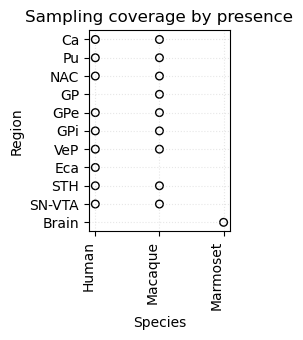

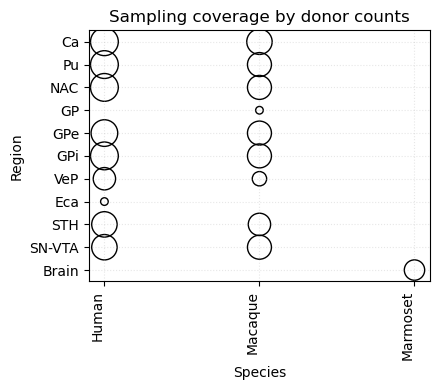

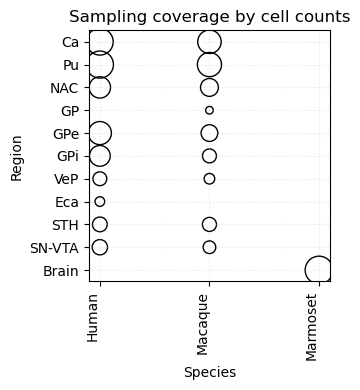

In [26]:
counts, presence = species_region_dotplot(
    adata,
    species_key="organism",
    region_key="anatomical_region_merged",
    size_by="presence", # {"cells","donors","presence"}
    region_order=my_anatomical_region_order,
    figsize=(2.5,3.5)
)

counts, presence = species_region_dotplot(
    adata,
    species_key="organism",
    region_key="anatomical_region_merged",
    size_by="donors",
    region_order=my_anatomical_region_order,
    figsize=(4.5,4)
)

counts, presence = species_region_dotplot(
    adata,
    species_key="organism",
    region_key="anatomical_region_merged",
    size_by="cells",
    region_order=my_anatomical_region_order,
    figsize=(3.5,4)
)